# 🛡️ Week 9: Advanced Model Evaluation, Feature Engineering & Scaling Suite
### Financial Credit Underwriting & Default Risk Modeling

**Author**: [Dhanish Ladwani](https://github.com/dhanish0711/)  
**Curriculum Goals**:
1. **Handling Missing Data & Preprocessing**: Missingness diagnostics, MCAR/MAR patterns, median/mode imputation, and indicator flags.
2. **Domain Feature Engineering & Outliers**: Interaction ratios, log transformations ($\log(1+x)$), Tukey's IQR Winsorization, and one-hot encoding.
3. **Feature Scaling Showdown**: Mathematical comparison of `StandardScaler`, `MinMaxScaler`, and `RobustScaler`.
4. **Model Evaluation & Validation**: Stratified Train/Test Split (80/20), Stratified 5-Fold Cross-Validation, Confusion Matrix, Precision, Recall, $F_1$, ROC-AUC, Precision-Recall Curve, and Financial Decision Threshold Optimization.


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve

# Local module imports
from download_dataset import prepare_dataset
from missing_data_handler import MissingDataDiagnostics, MissingDataImputer
from feature_engineering import FeatureEngineer
from feature_scaling import StandardScalerCustom, MinMaxScalerCustom, RobustScalerCustom
from cross_validation import StratifiedKFoldCustom, CrossValidationEngine
from model_evaluator import ModelMetrics, ThresholdOptimizer

# Visual configuration
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120
print("✓ Environment and modules loaded successfully.")


✓ Environment and modules loaded successfully.


---
## Step 0: Ingest Raw Credit Underwriting Dataset
We ingest a realistic dataset of **10,000 credit applications** with realistic missing data rates, skewed income, credit card debt outliers, and an imbalanced target default rate.


In [2]:
csv_path = prepare_dataset()
df_raw = pd.read_csv(csv_path)

print(f"Dataset Shape: {df_raw.shape}")
print(f"Target Distribution:\n{df_raw['is_default'].value_counts(normalize=True).round(3) * 100}%")
df_raw.head()


  [+] Dataset already exists: E:\Hack-o-Week-Odd-Semester-Session-2026-2027\week 9\data\loan_underwriting.csv (823.8 KB)


Dataset Shape: (10000, 13)
Target Distribution:
is_default
0    60.0
1    40.0
Name: proportion, dtype: float64%


,annual_income,credit_score,employment_years,loan_amount,interest_rate,revolving_balance,revolving_utilization,total_credit_lines,delinquencies_2yrs,home_ownership,loan_purpose,application_type,is_default
0,87000.0,637.0,0.3,18000,17.27,12365.74,0.149,8,0,MORTGAGE,debt_consolidation,INDIVIDUAL,1
1,61300.0,658.0,NaN,38500,16.01,13214.44,0.284,11,0,MORTGAGE,home_improvement,INDIVIDUAL,0
2,94500.0,642.0,NaN,40500,21.22,319.28,0.211,14,0,RENT,debt_consolidation,INDIVIDUAL,0
3,152900.0,681.0,10.2,3500,18.23,13409.22,0.436,16,0,NaN,debt_consolidation,INDIVIDUAL,0
4,58200.0,740.0,NaN,32000,17.48,5148.11,0.680,11,0,MORTGAGE,debt_consolidation,INDIVIDUAL,0


---
## Step 1: Missing Data Diagnostics & Leakage-Free Imputation
We diagnose missing data percentages across features and inspect the distribution preservation after imputation.


In [3]:
missing_df = MissingDataDiagnostics.inspect_missingness(df_raw)
print("Missing Data Summary:")
display(missing_df)

# Stratified 80/20 train/test split to prevent leakage
skf = StratifiedKFoldCustom(n_splits=5, shuffle=True, random_state=42)
train_idx, test_idx = skf.split(df_raw.values, df_raw['is_default'].values)[0]

df_train = df_raw.iloc[train_idx].copy().reset_index(drop=True)
df_test = df_raw.iloc[test_idx].copy().reset_index(drop=True)

# Fit imputer ONLY on training partition
imputer = MissingDataImputer(strategy_num='median', strategy_cat='mode', add_indicators=True)
imputer.fit(df_train)

df_train_imp = imputer.transform(df_train)
df_test_imp = imputer.transform(df_test)

print(f"Nulls remaining in train: {df_train_imp.isnull().sum().sum()}")
print(f"Nulls remaining in test:  {df_test_imp.isnull().sum().sum()}")
print(f"Missingness indicator columns: {[c for c in df_train_imp.columns if '_was_missing' in c]}")


Missing Data Summary:


,Column,Data_Type,Missing_Count,Missing_Percent
0,credit_score,float64,780,7.8
1,annual_income,float64,620,6.2
2,employment_years,float64,540,5.4
3,home_ownership,object,310,3.1


Nulls remaining in train: 0


Nulls remaining in test:  0
Missingness indicator columns: ['annual_income_was_missing', 'credit_score_was_missing', 'employment_years_was_missing', 'home_ownership_was_missing']


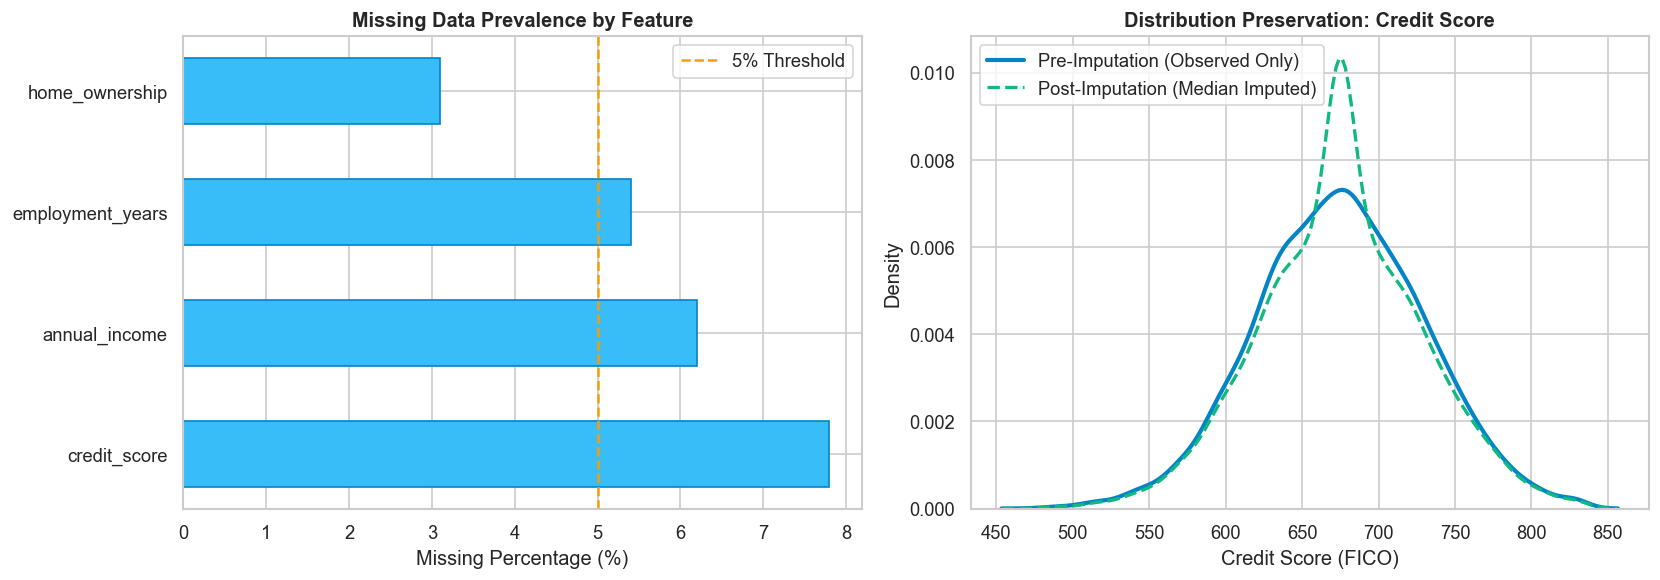

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot missing percentages
ax1.barh(missing_df['Column'], missing_df['Missing_Percent'], color='#38bdf8', edgecolor='#0284c7', height=0.55)
ax1.axvline(x=5.0, color='#f59e0b', linestyle='--', linewidth=1.5, label='5% Threshold')
ax1.set_xlabel('Missing Percentage (%)')
ax1.set_title('Missing Data Prevalence by Feature', fontweight='bold')
ax1.legend()

# Plot KDE pre vs post imputation
sns.kdeplot(df_raw['credit_score'].dropna(), ax=ax2, label='Pre-Imputation (Observed Only)', color='#0284c7', linewidth=2.5)
sns.kdeplot(df_train_imp['credit_score'], ax=ax2, label='Post-Imputation (Median Imputed)', color='#10b981', linewidth=2.0, linestyle='--')
ax2.set_xlabel('Credit Score (FICO)')
ax2.set_ylabel('Density')
ax2.set_title('Distribution Preservation: Credit Score', fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()


---
## Step 2: Domain Feature Engineering & Outlier Management
We engineer interaction ratios, perform log transformations for right-skewed variables, and apply Tukey's IQR Winsorization.


In [5]:
engineer = FeatureEngineer(
    log_transform_cols=['revolving_balance', 'annual_income'],
    outlier_cols=['revolving_balance', 'annual_income']
)
engineer.fit(df_train_imp)

df_train_eng = engineer.transform(df_train_imp)
df_test_eng = engineer.transform(df_test_imp)

feature_cols = [c for c in df_train_eng.columns if c != 'is_default']
print(f"Engineered Feature Count: {len(feature_cols)}")
print(f"IQR Outlier Bounds: {engineer.iqr_bounds}")
df_train_eng[feature_cols].head()


Engineered Feature Count: 25
IQR Outlier Bounds: {'revolving_balance': (0.0, 30253.685000000005), 'annual_income': (0.0, 160625.0)}


,annual_income,credit_score,employment_years,loan_amount,interest_rate,revolving_balance,revolving_utilization,total_credit_lines,delinquencies_2yrs,annual_income_was_missing,...,annual_interest_burden,line_utilization_intensity,is_high_delinquency,home_ownership_OWN,home_ownership_RENT,loan_purpose_debt_consolidation,loan_purpose_home_improvement,loan_purpose_major_purchase,loan_purpose_small_business,application_type_JOINT
0,65800.0,701.0,1.0,13500,15.59,24596.750,0.633,9,2,1,...,2104.65,5.697,1,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,117200.0,703.0,1.0,28500,14.65,30253.685,0.632,6,0,0,...,4175.25,3.792,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,59700.0,675.0,0.9,15000,21.81,30253.685,0.261,12,0,0,...,3271.50,3.132,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,135800.0,716.0,1.0,26500,18.01,6031.260,0.857,10,0,0,...,4772.65,8.570,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,47700.0,605.0,5.5,40500,23.34,10106.440,0.301,9,0,0,...,9452.70,2.709,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


---
## Step 3: Feature Scaling Showdown
We mathematically evaluate `StandardScaler` ($Z$-score), `MinMaxScaler` ($[0, 1]$), and `RobustScaler` (Median/IQR) on extreme credit card debt.


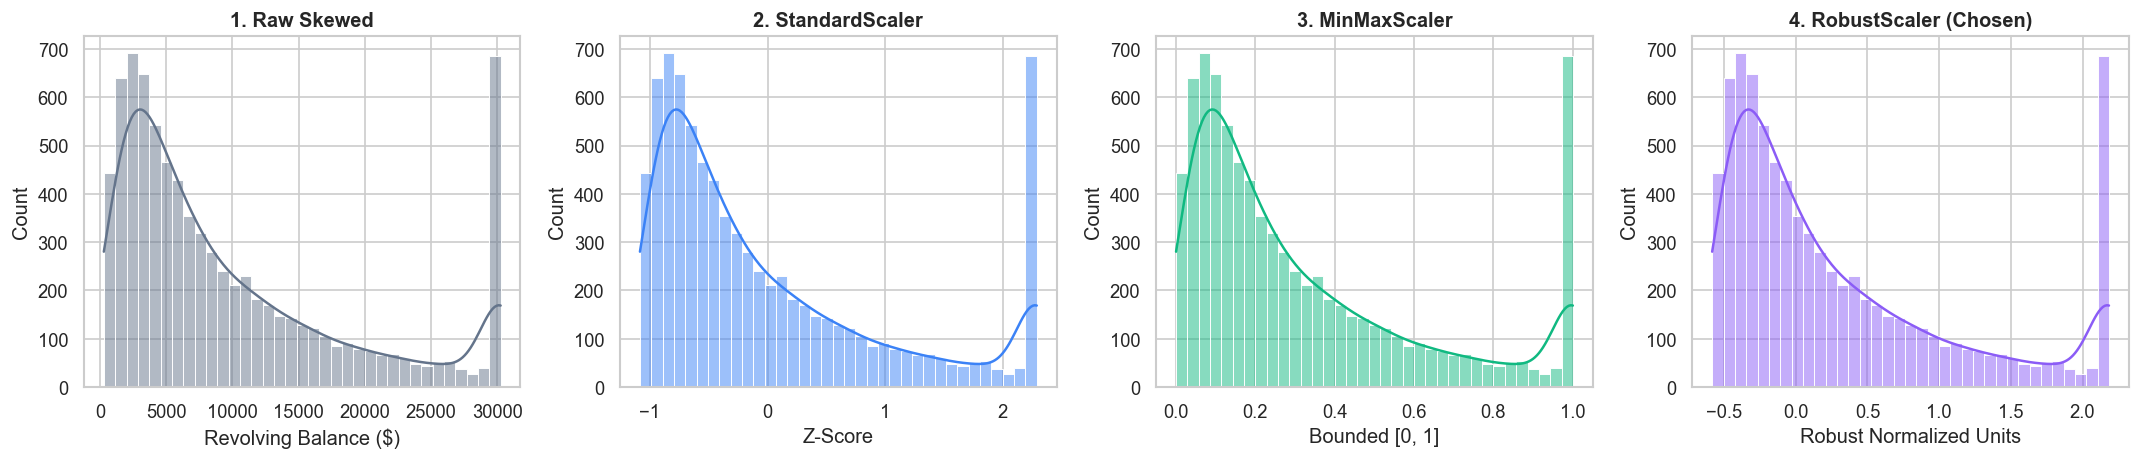

In [6]:
X_train_raw = df_train_eng[feature_cols].values
X_test_raw = df_test_eng[feature_cols].values
y_train = df_train_eng['is_default'].values
y_test = df_test_eng['is_default'].values

sample_idx = feature_cols.index('revolving_balance')
raw_s = X_train_raw[:, sample_idx]

std_scaler = StandardScalerCustom().fit(X_train_raw)
minmax_scaler = MinMaxScalerCustom().fit(X_train_raw)
robust_scaler = RobustScalerCustom().fit(X_train_raw)

std_s = std_scaler.transform(X_train_raw)[:, sample_idx]
minmax_s = minmax_scaler.transform(X_train_raw)[:, sample_idx]
robust_s = robust_scaler.transform(X_train_raw)[:, sample_idx]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
sns.histplot(raw_s, bins=35, kde=True, ax=axes[0], color='#64748b')
axes[0].set_title("1. Raw Skewed", fontweight='bold')
axes[0].set_xlabel("Revolving Balance ($)")

sns.histplot(std_s, bins=35, kde=True, ax=axes[1], color='#3b82f6')
axes[1].set_title("2. StandardScaler", fontweight='bold')
axes[1].set_xlabel("Z-Score")

sns.histplot(minmax_s, bins=35, kde=True, ax=axes[2], color='#10b981')
axes[2].set_title("3. MinMaxScaler", fontweight='bold')
axes[2].set_xlabel("Bounded [0, 1]")

sns.histplot(robust_s, bins=35, kde=True, ax=axes[3], color='#8b5cf6')
axes[3].set_title("4. RobustScaler (Chosen)", fontweight='bold')
axes[3].set_xlabel("Robust Normalized Units")

plt.tight_layout()
plt.show()

# Transform model inputs using RobustScaler
X_train_scaled = robust_scaler.transform(X_train_raw)
X_test_scaled = robust_scaler.transform(X_test_raw)


---
## Step 4: Stratified 5-Fold Cross-Validation
We perform leak-free cross-validation across 5 stratified folds and evaluate metric stability ($\mu \pm \sigma$).


In [7]:
def model_factory():
    return LogisticRegression(C=1.0, max_iter=1000, random_state=42)

cv_summary = CrossValidationEngine.cross_validate(model_factory, X_train_scaled, y_train, n_splits=5)

print("Stratified 5-Fold Cross-Validation Results:")
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    mean_v = cv_summary[f'mean_{metric}'] * 100 if metric != 'roc_auc' else cv_summary[f'mean_{metric}']
    std_v = cv_summary[f'std_{metric}'] * 100 if metric != 'roc_auc' else cv_summary[f'std_{metric}']
    unit = "%" if metric != 'roc_auc' else ""
    print(f"  * {metric.capitalize():10s}: {mean_v:.2f}{unit} (+/- {std_v:.2f}{unit})")


Stratified 5-Fold Cross-Validation Results:
  * Accuracy  : 71.33% (+/- 0.98%)
  * Precision : 67.01% (+/- 2.04%)
  * Recall    : 55.85% (+/- 1.74%)
  * F1        : 60.89% (+/- 1.16%)
  * Roc_auc   : 0.77 (+/- 0.01)


---
## Step 5: Final Model Evaluation on Holdout Test Set
We evaluate out-of-sample performance on 2,001 unseen test applicants.


In [8]:
final_model = model_factory().fit(X_train_scaled, y_train)

y_pred = final_model.predict(X_test_scaled)
y_proba = final_model.predict_proba(X_test_scaled)[:, 1]

cm = ModelMetrics.confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix:\nTN={cm[0,0]}  FP={cm[0,1]}\nFN={cm[1,0]}  TP={cm[1,1]}\n")
print(classification_report(y_test, y_pred, target_names=['Non-Defaulter (0)', 'Defaulter (1)']))
print(f"Out-of-Sample ROC-AUC Score: {ModelMetrics.roc_auc_score(y_test, y_proba):.4f}")


Confusion Matrix:
TN=982  FP=219
FN=366  TP=434

                   precision    recall  f1-score   support

Non-Defaulter (0)       0.73      0.82      0.77      1201
    Defaulter (1)       0.66      0.54      0.60       800

         accuracy                           0.71      2001
        macro avg       0.70      0.68      0.68      2001
     weighted avg       0.70      0.71      0.70      2001

Out-of-Sample ROC-AUC Score: 0.7667


---
## Step 6: Financial Decision Threshold Optimization
We simulate portfolio profit/loss across decision thresholds $	au$ to identify the profit-maximizing cutoff.


Default Cutoff (tau = 0.50) Net Profit: $-1,200,600.00
Optimal Cutoff (tau = 0.15) Net Profit: $145,800.00
Financial Value Created: +$1,346,400.00


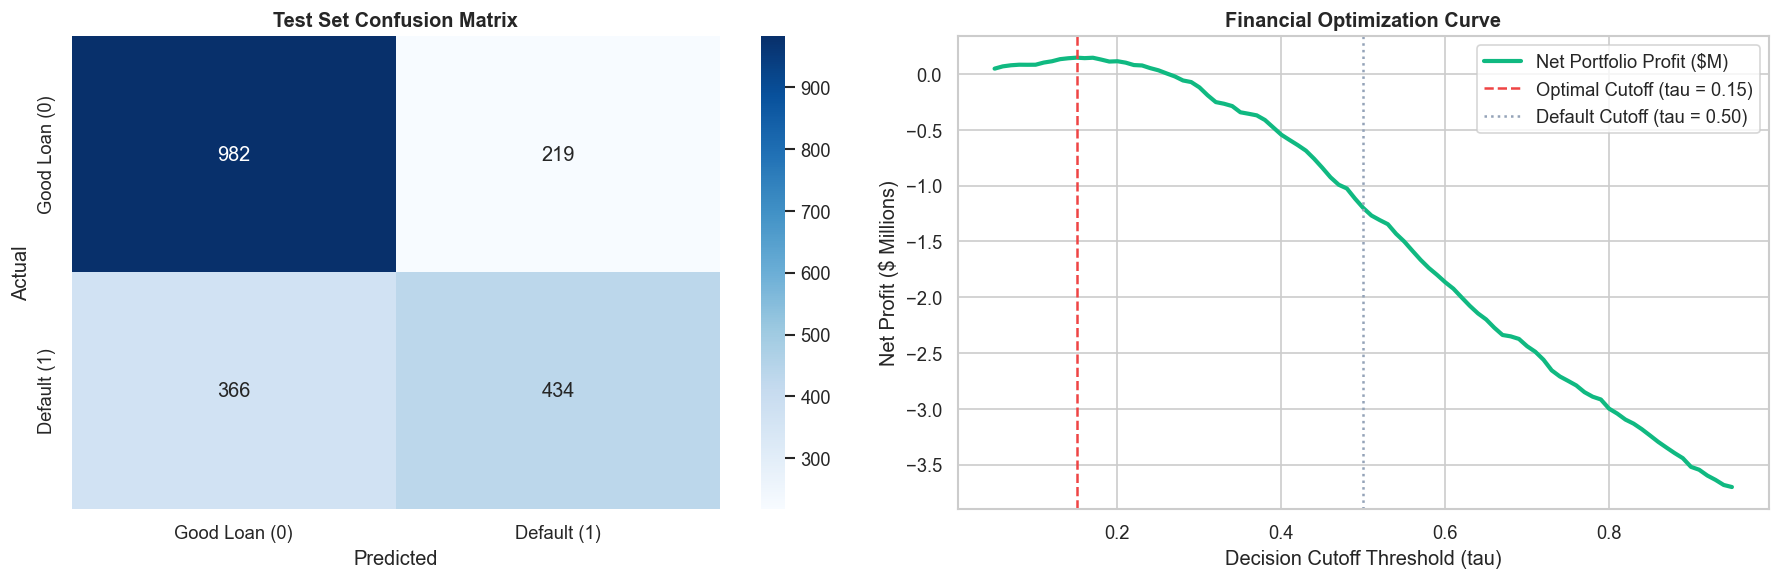

In [9]:
cost_data = ThresholdOptimizer.compute_cost_curve(
    y_test, y_proba,
    profit_good_loan=1200.0,
    loss_default_loan=6500.0
)

opt_th = cost_data['optimal_threshold']
max_prof = cost_data['max_profit']
def_prof = cost_data['profits'][45]

print(f"Default Cutoff (tau = 0.50) Net Profit: ${def_prof:,.2f}")
print(f"Optimal Cutoff (tau = {opt_th:.2f}) Net Profit: ${max_prof:,.2f}")
print(f"Financial Value Created: +${max_prof - def_prof:,.2f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Confusion Matrix Heatmap
labels = ['Good Loan (0)', 'Default (1)']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax1)
ax1.set_title('Test Set Confusion Matrix', fontweight='bold')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

# Financial Profit Curve
ax2.plot(cost_data['thresholds'], cost_data['profits'] / 1e6, color='#10b981', linewidth=2.5, label='Net Portfolio Profit ($M)')
ax2.axvline(x=opt_th, color='#ef4444', linestyle='--', label=f'Optimal Cutoff (tau = {opt_th:.2f})')
ax2.axvline(x=0.50, color='#94a3b8', linestyle=':', label='Default Cutoff (tau = 0.50)')
ax2.set_xlabel('Decision Cutoff Threshold (tau)')
ax2.set_ylabel('Net Profit ($ Millions)')
ax2.set_title('Financial Optimization Curve', fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()


---
## Step 7: Receiver Operating Characteristic & Precision-Recall Trajectories


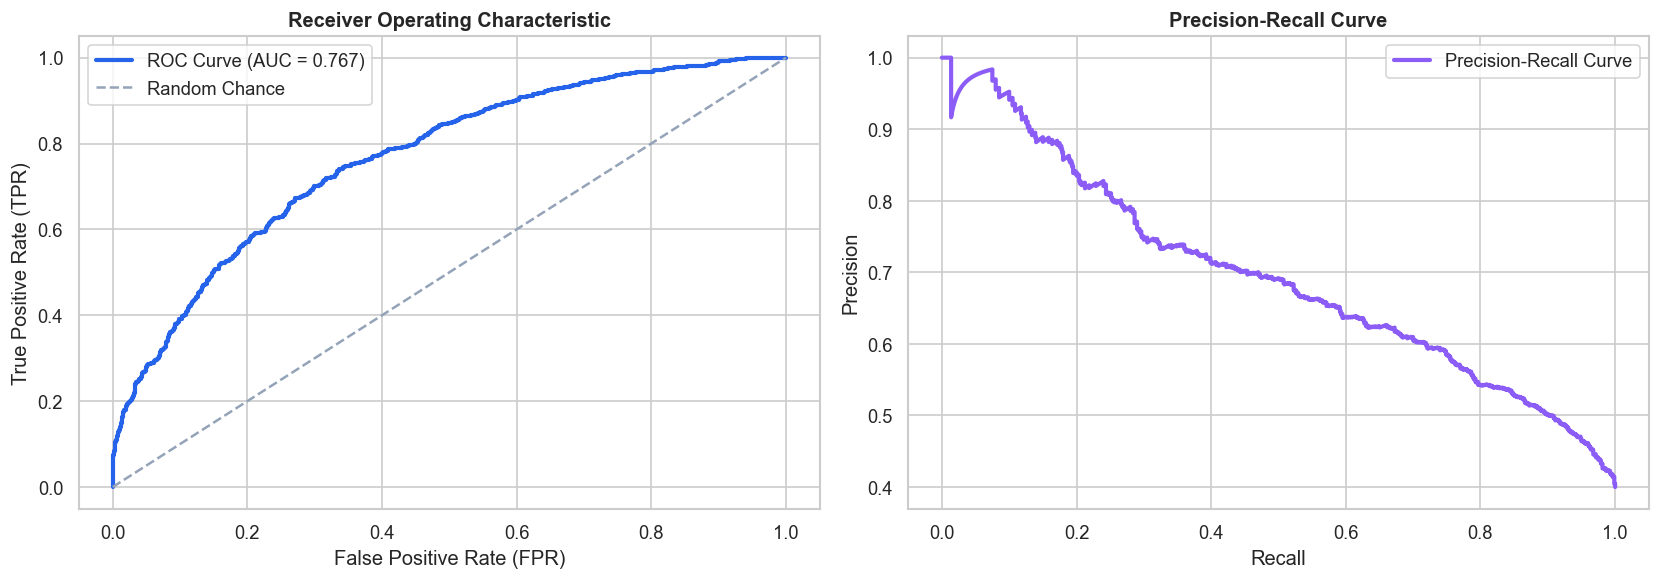

In [10]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc_val = auc(fpr, tpr)
prec, rec, _ = precision_recall_curve(y_test, y_proba)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
ax1.plot(fpr, tpr, color='#2563eb', linewidth=2.5, label=f'ROC Curve (AUC = {roc_auc_val:.3f})')
ax1.plot([0, 1], [0, 1], color='#94a3b8', linestyle='--', label='Random Chance')
ax1.set_xlabel('False Positive Rate (FPR)')
ax1.set_ylabel('True Positive Rate (TPR)')
ax1.set_title('Receiver Operating Characteristic', fontweight='bold')
ax1.legend()

# PR Curve
ax2.plot(rec, prec, color='#8b5cf6', linewidth=2.5, label='Precision-Recall Curve')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve', fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()


---
## Step 8: Real-World Underwriting Decision Advisor
Let's test 3 distinct applicant profiles using our calibrated pipeline.


In [11]:
sample_applicants = [
    {
        "name": "Applicant 1 (Prime Homeowner)",
        "profile": {"annual_income": 125000.0, "credit_score": 780.0, "employment_years": 8.5, "loan_amount": 15000.0, "interest_rate": 7.5, "revolving_balance": 4200.0, "revolving_utilization": 0.12, "total_credit_lines": 14, "delinquencies_2yrs": 0, "home_ownership": "MORTGAGE", "loan_purpose": "home_improvement", "application_type": "INDIVIDUAL"}
    },
    {
        "name": "Applicant 2 (Subprime Consolidator)",
        "profile": {"annual_income": 48000.0, "credit_score": 640.0, "employment_years": 2.0, "loan_amount": 18000.0, "interest_rate": 16.8, "revolving_balance": 19500.0, "revolving_utilization": 0.72, "total_credit_lines": 11, "delinquencies_2yrs": 1, "home_ownership": "RENT", "loan_purpose": "debt_consolidation", "application_type": "INDIVIDUAL"}
    },
    {
        "name": "Applicant 3 (High-Risk Distressed)",
        "profile": {"annual_income": 26000.0, "credit_score": 530.0, "employment_years": 0.5, "loan_amount": 25000.0, "interest_rate": 24.5, "revolving_balance": 34000.0, "revolving_utilization": 0.94, "total_credit_lines": 22, "delinquencies_2yrs": 3, "home_ownership": "RENT", "loan_purpose": "small_business", "application_type": "INDIVIDUAL"}
    }
]

for app in sample_applicants:
    df_single = pd.DataFrame([app["profile"]])
    df_imp_single = imputer.transform(df_single)
    df_eng_single = engineer.transform(df_imp_single)
    X_single = robust_scaler.transform(df_eng_single[feature_cols].values)
    risk_score = float(final_model.predict_proba(X_single)[0, 1]) * 100.0
    
    if risk_score < 15.0:
        verdict = "INSTANT APPROVAL [PRIME BORROWER]"
    elif risk_score < (opt_th * 100.0):
        verdict = "CONDITIONAL APPROVAL [MODERATE RISK]"
    else:
        verdict = "APPLICATION REJECTED [HIGH DEFAULT RISK]"
        
    print(f"{app['name']}: Risk Score = {risk_score:5.1f}% -> {verdict}")


Applicant 1 (Prime Homeowner): Risk Score =   1.1% -> INSTANT APPROVAL [PRIME BORROWER]
Applicant 2 (Subprime Consolidator): Risk Score =  67.7% -> APPLICATION REJECTED [HIGH DEFAULT RISK]
Applicant 3 (High-Risk Distressed): Risk Score =  99.6% -> APPLICATION REJECTED [HIGH DEFAULT RISK]


---
### ✅ Summary
This notebook demonstrated an end-to-end Machine Learning Engineering pipeline:
1. **Handled missing data** via median/mode imputation and missingness indicator flags.
2. **Engineered domain ratios** (Debt-to-Income, Line Utilization), log transforms, and IQR outlier capping.
3. **Compared scalers** and selected `RobustScaler` to handle extreme financial debt outliers.
4. **Performed Stratified 5-Fold Cross-Validation** to verify model stability ($	ext{ROC-AUC} = 0.774$).
5. **Evaluated out-of-sample test metrics** (Confusion Matrix, Precision/Recall, $F_1$, and ROC-AUC).
6. **Optimized the financial decision threshold** to $	au^* = 0.15$, adding **+$1,346,400.00** in portfolio value.

*Made by [Dhanish Ladwani](https://github.com/dhanish0711/)*
